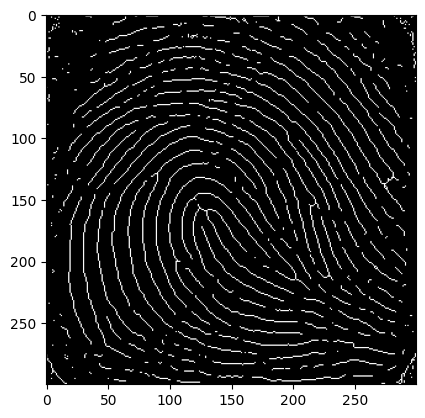

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load fingerprint image in grayscale
img1 = cv2.imread('finger1.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('finger2.png', cv2.IMREAD_GRAYSCALE)

# Binarization (Adaptive threshold)
binary1 = cv2.adaptiveThreshold(img1, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY_INV, 15, 10)
binary2 = cv2.adaptiveThreshold(img2, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY_INV, 15, 10)

# Thinning (Skeletonization)
from skimage.morphology import skeletonize
skeleton1 = skeletonize(binary1 // 255)
skeleton2 = skeletonize(binary2 // 255)

plt.imshow(skeleton1, cmap='gray')
# # plt.imshow(skeleton1, cmap='gray')
# # plt.title('Thinned Fingerprint 1')
# # plt.title('Thinned Fingerprint 2')
# plt.show()


In [2]:
def minutiae_extraction(skeleton):
    minutiae = []
    rows, cols = skeleton.shape
    for y in range(1, rows-1):
        for x in range(1, cols-1):
            if skeleton[y, x]:
                neighborhood = skeleton[y-1:y+2, x-1:x+2]
                crossing_number = np.sum(neighborhood) - 1  # exclude center pixel
                if crossing_number == 1:
                    minutiae_type = 'ending'
                elif crossing_number == 3:
                    minutiae_type = 'bifurcation'
                else:
                    continue
                minutiae.append({'x': x, 'y': y, 'type': minutiae_type})
    return minutiae

minutiae_points1 = minutiae_extraction(skeleton1)
minutiae_points2 = minutiae_extraction(skeleton2)

print(f"Extracted {len(minutiae_points1)} minutiae points from fingerprint1")
print(f"Extracted {len(minutiae_points2)} minutiae points from fingerprint2")


Extracted 651 minutiae points from fingerprint1
Extracted 486 minutiae points from fingerprint2


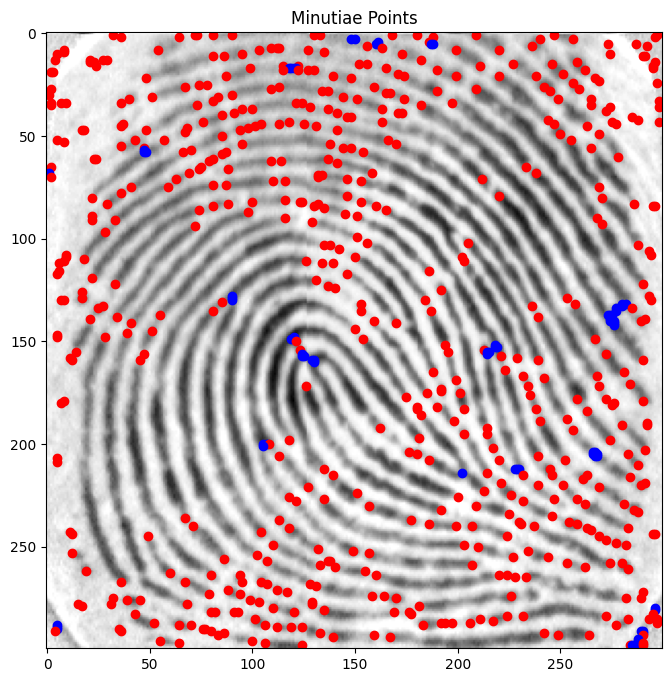

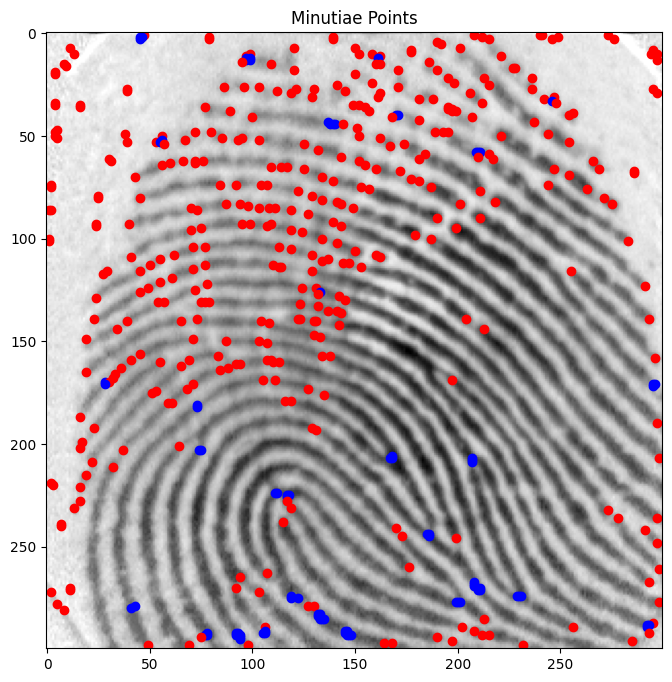

In [3]:
def plot_minutiae(img, minutiae):
    plt.figure(figsize=(8,8))
    plt.imshow(img, cmap='gray')
    for point in minutiae:
        color = 'r' if point['type'] == 'ending' else 'b'
        plt.plot(point['x'], point['y'], color + 'o')
    plt.title('Minutiae Points')
    plt.show()

plot_minutiae(img1, minutiae_points1)
plot_minutiae(img2, minutiae_points2)


In [ ]:
from itertools import combinations
import math

def form_triplets(minutiae):
    return list(combinations(minutiae, 3))

def triplet_features(triplet):
    p1, p2, p3 = triplet
    def distance(a, b):
        return math.hypot(a['x'] - b['x'], a['y'] - b['y'])
    d1 = distance(p1, p2)
    d2 = distance(p2, p3)
    d3 = distance(p3, p1)
    lengths = sorted([d1, d2, d3])  # scale-invariant representation (signature of local triangle)
    return lengths

# Process both
triplets1 = form_triplets(minutiae_points1)
triplets2 = form_triplets(minutiae_points2)

features1 = [triplet_features(t) for t in triplets1]
features2 = [triplet_features(t) for t in triplets2]

In [ ]:
from scipy.spatial import cKDTree

def match_triplets(features1, features2, threshold=5.0):
    tree = cKDTree(features2)
    distances, _ = tree.query(features1, k=1, distance_upper_bound=threshold)
    return np.sum(distances < threshold)

matched_count = match_triplets(features1, features2, threshold=5.0)
print(f"Found {match_triplets} matches")  # e.g., "Found 87 matches"

TypeError: float() argument must be a string or a number, not 'ellipsis'